In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/dataset.yaml
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/README.md
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/.gitattributes
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/failed_urls.txt
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/scraper.log
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/statistics.json
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/classes.txt
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/annotated_images/mostvisited_tinyurl.com_1729630335_annotated.png
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/annotated_images/productivity_www.anydo.com_1729629633_annotated.png
/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/yolo_dataset/annotated_images/off

In [23]:
# Run this first after restart to confirm GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU name: Tesla T4


In [24]:
import os

# See exactly what's mounted
print("Contents of /kaggle/input:")
for item in os.listdir("/kaggle/input"):
    print(f"  {item}")

Contents of /kaggle/input:
  datasets


In [25]:
import os

# Check full structure
for root, dirs, files in os.walk("/kaggle/input/datasets"):
    level = root.replace("/kaggle/input/datasets", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 2:  # only show files for first 2 levels
        for f in files[:5]:
            print(f"{indent}  📄 {f}")
        if len(files) > 5:
            print(f"{indent}  ... and {len(files)-5} more files")

📁 datasets/
  📁 daudaudinang/
    📁 ui-elements-detection-dataset/
      📁 yolo_dataset/
        📁 annotated_images/
        📁 labels/
        📁 images/
      📁 val/
        📁 labels/
        📁 images/
      📁 .git/
        📁 info/
        📁 refs/
          📁 heads/
          📁 remotes/
            📁 origin/
        📁 hooks/
        📁 lfs/
          📁 objects/
            📁 d8/
              📁 02/
              📁 a7/
              📁 fb/
              📁 c1/
            📁 0d/
              📁 e2/
              📁 70/
              📁 ba/
              📁 cc/
              📁 1f/
              📁 21/
            📁 47/
              📁 b1/
              📁 e3/
              📁 6c/
            📁 17/
              📁 5b/
              📁 39/
              📁 bb/
              📁 c3/
              📁 5a/
              📁 ad/
            📁 81/
              📁 d5/
              📁 2e/
              📁 1e/
              📁 99/
              📁 7f/
              📁 e9/
            📁 c5/
              📁 e0/
         

In [26]:
import os

base = "/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset"

# Check image and label counts
for split in ["train", "val", "test"]:
    images = os.listdir(f"{base}/{split}/images")
    labels = os.listdir(f"{base}/{split}/labels")
    print(f"{split}: {len(images)} images, {len(labels)} labels")

train: 544 images, 544 labels
val: 71 images, 71 labels
test: 76 images, 76 labels


In [27]:
# Check what classes exist — look at a sample label
for split in ["train", "val", "test"]:
    label_dir = f"{base}/{split}/labels"
    files = os.listdir(label_dir)
    if files:
        with open(f"{label_dir}/{files[0]}") as f:
            print(f"\nSample label from {split}:")
            print(f.read()[:300])
        break


Sample label from train:
1 0.8579915364583334 0.1274740967056323 0.02431640625 0.01700318809776833
0 0.7799519856770833 0.15621679064824653 0.027596028645833333 0.04144527098831031
1 0.21666666666666667 0.21891604675876727 0.020833333333333332 0.040382571732199786
1 0.23958333333333334 0.21891604675876727 0.0208333333333333


In [28]:
# Find the data.yaml file
for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith(".yaml"):
            full = os.path.join(root, f)
            print(f"Found: {full}")
            with open(full) as file:
                print(file.read())

Found: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/dataset.yaml
path: ../yolo_dataset
train: ../train/images
val: ../val/images
test: ../test/images
names:
  0: link
  1: button
  2: input
  3: select
  4: textarea
  5: label
  6: checkbox
  7: radio
  8: dropdown
  9: slider
  10: toggle
  11: menu_item
  12: clickable
  13: icon
  14: image
  15: text
nc: 16



In [29]:
# Cell 1 — Install YOLOv8
!pip install ultralytics -q
from ultralytics import YOLO
print("✅ Ultralytics ready")

✅ Ultralytics ready


In [30]:
# Cell 2 — Create correct data.yaml
# The original yaml has wrong paths, we fix them here
import yaml

base = "/kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset"

data = {
    "path": base,
    "train": f"{base}/train/images",
    "val":   f"{base}/val/images",
    "test":  f"{base}/test/images",
    "nc": 16,
    "names": {
        0: "link", 1: "button", 2: "input", 3: "select",
        4: "textarea", 5: "label", 6: "checkbox", 7: "radio",
        8: "dropdown", 9: "slider", 10: "toggle", 11: "menu_item",
        12: "clickable", 13: "icon", 14: "image", 15: "text"
    }
}

yaml_path = "/kaggle/working/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data, f, default_flow_style=False)

print("✅ data.yaml created")
print(open(yaml_path).read())

✅ data.yaml created
names:
  0: link
  1: button
  2: input
  3: select
  4: textarea
  5: label
  6: checkbox
  7: radio
  8: dropdown
  9: slider
  10: toggle
  11: menu_item
  12: clickable
  13: icon
  14: image
  15: text
nc: 16
path: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset
test: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/test/images
train: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/train/images
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/val/images



In [31]:
import torch
import os
from ultralytics import YOLO
from pathlib import Path

# ─── Device Selection ────────────────────────────────────────────────
device = 0 if torch.cuda.is_available() else "cpu"
print(f"🖥️  Training on: {'GPU (CUDA)' if device == 0 else 'CPU (no GPU found)'}")

# ─── Adaptive batch size ──────────────────────────────────────────────
# GPU: 16 is fine for 8GB VRAM. CPU: use 4–8 to avoid memory pressure.
batch = 16 if device != "cpu" else 4

# ─── Model ───────────────────────────────────────────────────────────
# yolov8m = good accuracy/speed balance.
# Upgrade to yolov8l or yolov8x if you have a strong GPU and want max accuracy.
model = YOLO("yolov8m.pt")

# ─── Training ────────────────────────────────────────────────────────
results = model.train(
    # Core
    data=yaml_path,
    epochs=100,           # More epochs — patience/early stopping will cut it short anyway
    imgsz=640,
    batch=batch,
    device=device,

    # Optimizer — AdamW converges better than default SGD for most UI datasets
    optimizer="AdamW",
    lr0=1e-3,             # Initial learning rate
    lrf=1e-2,             # Final lr = lr0 * lrf (cosine decay)
    momentum=0.937,
    weight_decay=5e-4,

    # Scheduler
    cos_lr=True,          # Cosine LR schedule — smoother decay than step

    # Regularization
    dropout=0.1,          # Light dropout to reduce overfitting
    label_smoothing=0.1,  # Prevents overconfident predictions

    # Early stopping
    patience=15,          # Stop if no improvement for 15 epochs

    # Augmentation — critical for small datasets
    augment=True,
    hsv_h=0.015,          # Hue variation
    hsv_s=0.7,            # Saturation variation
    hsv_v=0.4,            # Brightness variation
    degrees=5.0,          # Small rotation (UI elements are usually upright)
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0005,
    flipud=0.0,           # Don't flip UI upside down
    fliplr=0.5,           # Horizontal flip is fine
    mosaic=1.0,           # Mosaic augmentation — very effective
    mixup=0.1,            # MixUp augmentation
    copy_paste=0.1,       # Copy-paste augmentation

    # Warmup
    warmup_epochs=3.0,    # Gradual LR warmup prevents early instability
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    # Output
    name="ui_detector_v1",
    save=True,
    save_period=10,       # Save checkpoint every 10 epochs
    plots=True,           # Generate training plots

    # Performance
    workers=4 if device != "cpu" else 2,
    cache=True,           # Cache images in RAM for faster training
    exist_ok=True,        # Don't crash if run folder already exists
    verbose=True,
)

print(f"\n✅ Training complete!")
print(f"📁 Best weights: {results.save_dir}/weights/best.pt")
print(f"📊 Results:      {results.save_dir}/results.csv")

🖥️  Training on: GPU (CUDA)
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ui_detector_v1, nb

In [32]:
from ultralytics import YOLO

# Load best weights from training
model = YOLO(f"/kaggle/working/runs/detect/ui_detector_v1/weights/best.pt")

# Run validation on test split
metrics = model.val(
    data=yaml_path,
    split="test",
    iou=0.5,
    conf=0.001,        # Low conf threshold for best mAP calculation
    plots=True,
    save_json=True,    # Saves COCO-format results
    verbose=True,
)

print("\n📊 Test Set Metrics:")
print(f"   mAP@50:       {metrics.box.map50:.4f}")
print(f"   mAP@50-95:    {metrics.box.map:.4f}")
print(f"   Precision:    {metrics.box.mp:.4f}")
print(f"   Recall:       {metrics.box.mr:.4f}")

# Per-class breakdown
print("\n📋 Per-Class AP@50:")
names = model.names
for i, (name, ap) in enumerate(zip(names.values(), metrics.box.ap50)):
    print(f"   {name:<15} {ap:.4f}")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,849,024 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 2.0±0.2 ms, read: 20.3±13.0 MB/s, size: 390.1 KB)
val: Scanning /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/test/labels... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 117.6it/s 0.6s0.1s
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/test/images/ai_platforms_wandb.ai_1729627029.png: 29 duplicate labels removed
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/test/images/ai_platforms_wandb.ai_1729631881.png: 29 duplicate labels removed
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/test/images/creative_www.remove.bg_1729627000.png: 2 duplicate labels removed
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/test/images/e_commerce_www.walmart.com_1729626818.png: 1 dupl

/tmp/ipykernel_55/526549269.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", 16)


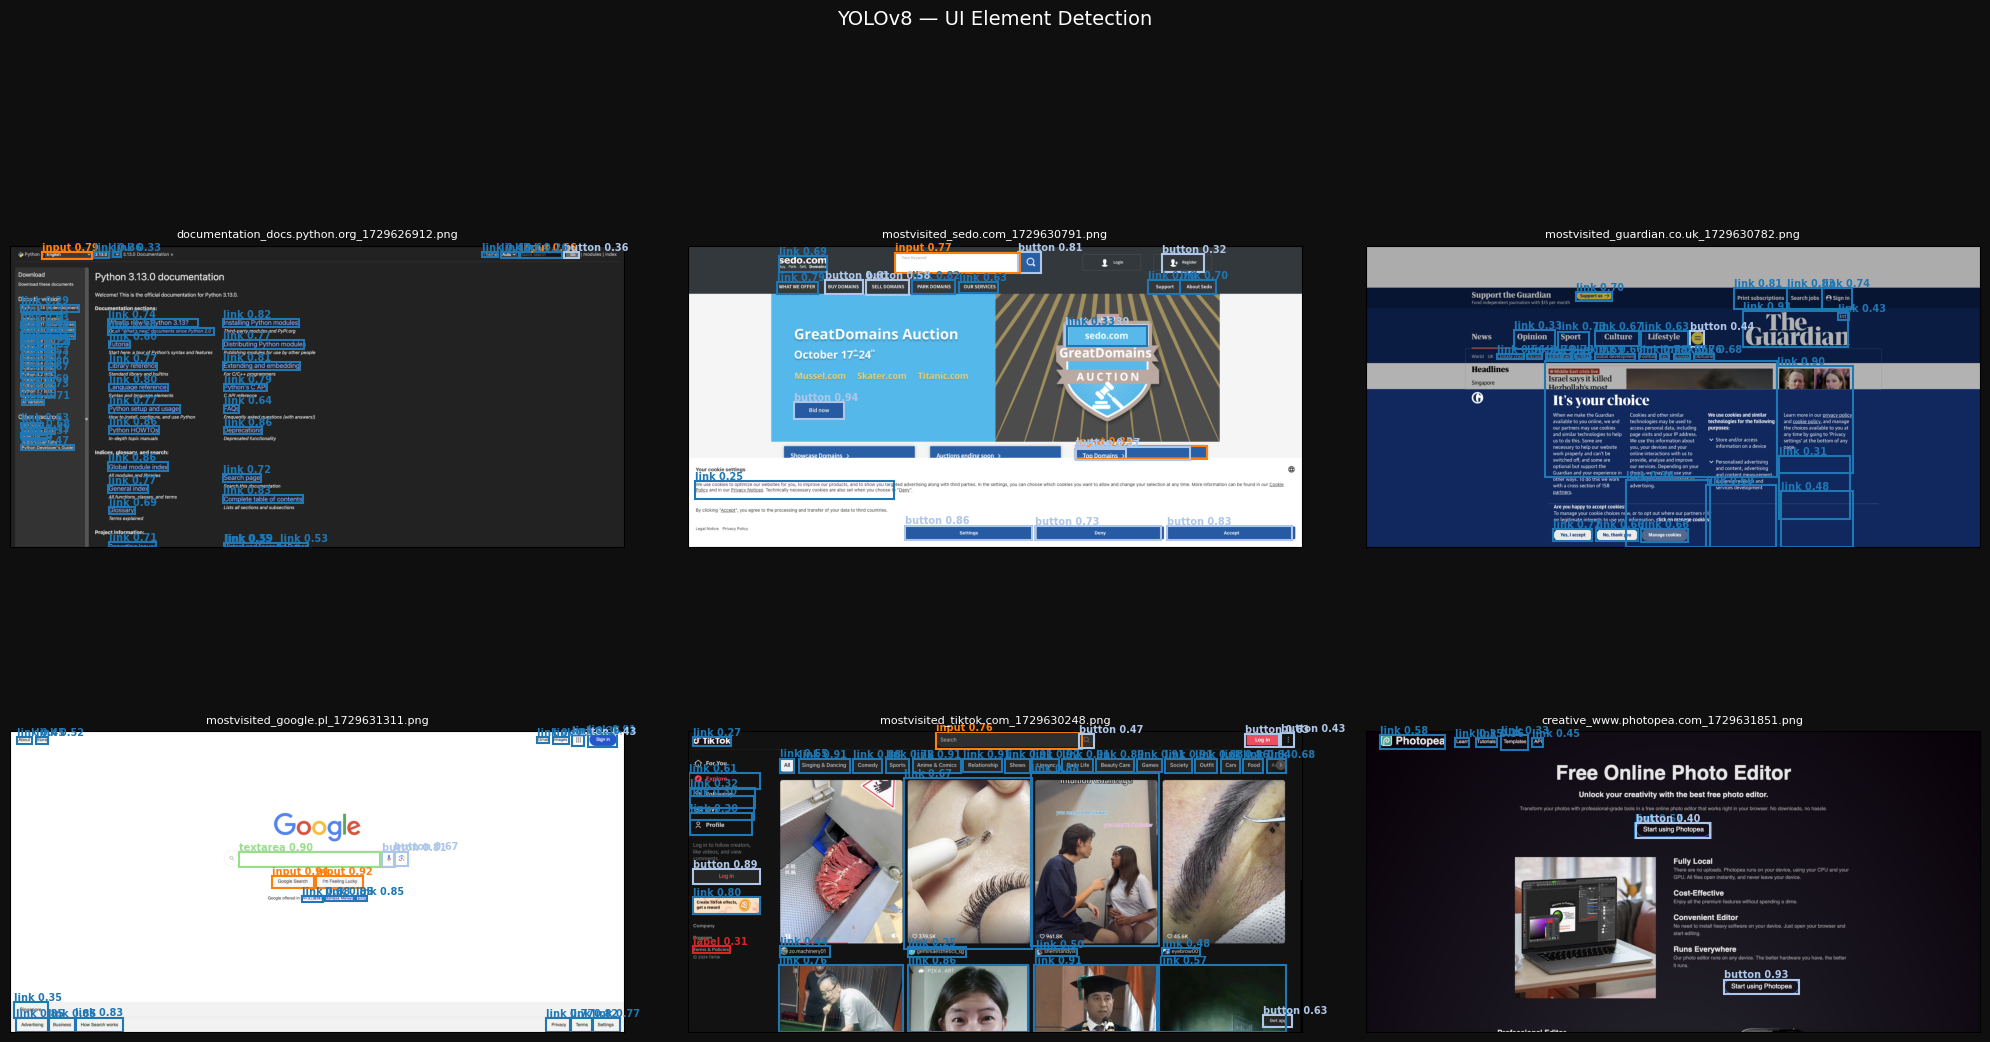

✅ Saved → /kaggle/working/predictions_sample.png


In [33]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import os

# Load model
model = YOLO(f"/kaggle/working/runs/detect/ui_detector_v1/weights/best.pt")

# Pick 6 random test images
test_img_dir = f"{base}/test/images"
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith((".jpg", ".png"))]
samples = random.sample(test_images, min(6, len(test_images)))

# Color palette for 16 classes
colors = plt.cm.get_cmap("tab20", 16)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor("#0f0f0f")
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_facecolor("#0f0f0f")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(os.path.basename(img_path), color="white", fontsize=8)

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = f"{model.names[cls]} {conf:.2f}"
        color = colors(cls)[:3]

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, color=color, fontsize=7, fontweight="bold")

plt.suptitle("YOLOv8 — UI Element Detection", color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/predictions_sample.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✅ Saved → /kaggle/working/predictions_sample.png")

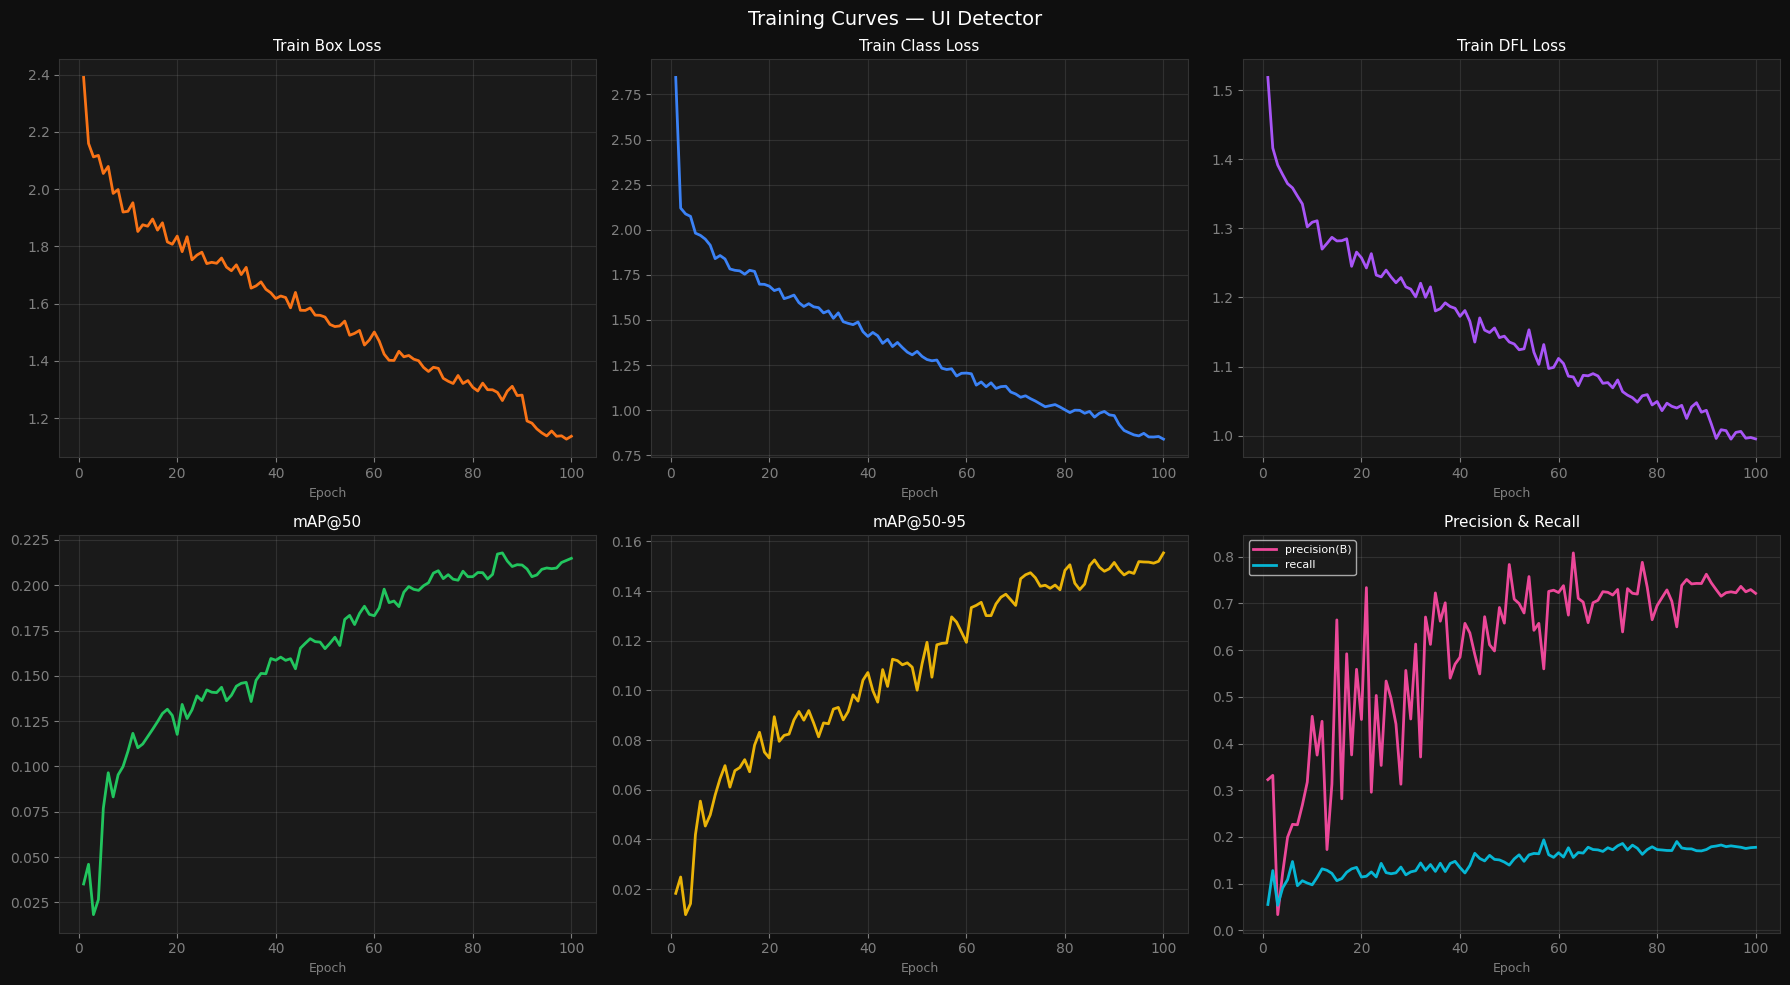

✅ Saved → /kaggle/working/training_curves.png


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = "/kaggle/working/runs/detect/ui_detector_v1/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0f0f0f")
axes = axes.flatten()

metrics_to_plot = [
    ("train/box_loss",       "Train Box Loss",    "#f97316"),
    ("train/cls_loss",       "Train Class Loss",  "#3b82f6"),
    ("train/dfl_loss",       "Train DFL Loss",    "#a855f7"),
    ("metrics/mAP50(B)",     "mAP@50",            "#22c55e"),
    ("metrics/mAP50-95(B)",  "mAP@50-95",         "#eab308"),
    ("metrics/precision(B)", "Precision & Recall","#ec4899"),
]

for ax, (col, title, color) in zip(axes, metrics_to_plot):
    ax.set_facecolor("#1a1a1a")
    ax.tick_params(colors="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

    if col in df.columns:
        ax.plot(df["epoch"], df[col], color=color, linewidth=2, label=col.split("/")[-1])

    # Overlay recall on the last panel
    if title == "Precision & Recall" and "metrics/recall(B)" in df.columns:
        ax.plot(df["epoch"], df["metrics/recall(B)"], color="#06b6d4", linewidth=2, label="recall")
        ax.legend(facecolor="#1a1a1a", labelcolor="white", fontsize=8)

    ax.set_title(title, color="white", fontsize=11)
    ax.set_xlabel("Epoch", color="gray", fontsize=9)
    ax.grid(alpha=0.15)

plt.suptitle("Training Curves — UI Detector", color="white", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✅ Saved → /kaggle/working/training_curves.png")

In [35]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/ui_detector_v1/weights/best.pt")

# ── ONNX (universal — works in browsers, mobile, servers) ────────────
model.export(
    format="onnx",
    imgsz=640,
    simplify=True,   # Graph simplification for faster inference
    opset=17,
    dynamic=False,   # Fixed input shape = faster
)
print("✅ Exported → best.onnx")

# ── TorchScript (pure PyTorch deployment) ───────────────────────────
model.export(format="torchscript", imgsz=640)
print("✅ Exported → best.torchscript")

print("\n📦 All exported files:")
import os
run_dir = "/kaggle/working/runs/detect/ui_detector_v1/weights/"
for f in os.listdir(run_dir):
    size_mb = os.path.getsize(os.path.join(run_dir, f)) / 1e6
    print(f"   {f:<30} {size_mb:.1f} MB")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,849,024 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/ui_detector_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 20, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 198ms
Prepared 2 packages in 3.24s
Installed 2 packages in 16ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 3.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export 

Sweeping confidence thresholds on val split...

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,849,024 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 2.0±0.7 ms, read: 515.1±371.6 MB/s, size: 323.2 KB)
val: Scanning /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/val/labels... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 802.9it/s 0.1s
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/val/images/dev_tools_jsfiddle.net_1729629915.png: 5 duplicate labels removed
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/val/images/development_developer.mozilla.org_1729626875.png: 3 duplicate labels removed
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-dataset/val/images/development_developer.mozilla.org_1729629644.png: 3 duplicate labels removed
val: /kaggle/input/datasets/daudaudinang/ui-elements-detection-datas

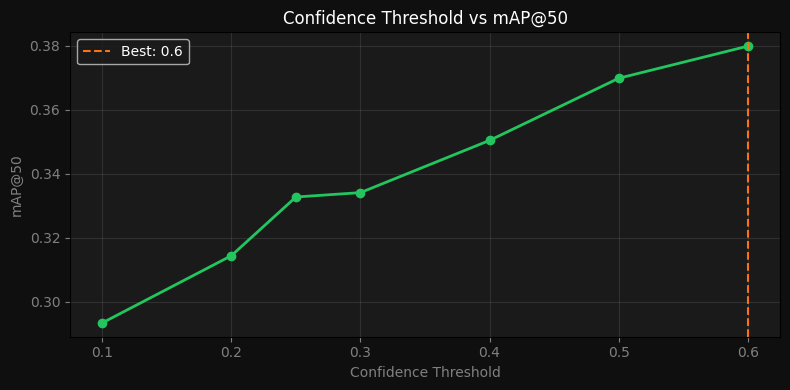

In [36]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("/kaggle/working/runs/detect/ui_detector_v1/weights/best.pt")

thresholds = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
maps = []

print("Sweeping confidence thresholds on val split...\n")
for conf in thresholds:
    m = model.val(data=yaml_path, conf=conf, iou=0.45, split="val", verbose=False)
    maps.append(m.box.map50)
    print(f"   conf={conf:.2f}  →  mAP@50: {m.box.map50:.4f}")

best_conf = thresholds[maps.index(max(maps))]
print(f"\n✅ Best confidence threshold: {best_conf}  (mAP@50: {max(maps):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#1a1a1a")
ax.plot(thresholds, maps, "o-", color="#22c55e", linewidth=2)
ax.axvline(best_conf, color="#f97316", linestyle="--", label=f"Best: {best_conf}")
ax.set_xlabel("Confidence Threshold", color="gray")
ax.set_ylabel("mAP@50", color="gray")
ax.set_title("Confidence Threshold vs mAP@50", color="white")
ax.tick_params(colors="gray")
ax.legend(facecolor="#1a1a1a", labelcolor="white")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("/kaggle/working/conf_sweep.png", dpi=150, facecolor="#0f0f0f")
plt.show()